In [1]:
include("1body_NM.jl")
using LinearAlgebra
using PolyChaos
using QuadGK
using Plots
using Plots.PlotMeasures
using ProgressMeter
using Kronecker
using JLD2
using SparseArrays
using .NM_measures_1body

In [31]:
P = set_P()
mu = 0.3
beta = 20.0
gamma = 0.01
T = 30.0

P.spec_fun = "ellipse"
P.T = T
P.v = 1000
P.Γ_L = gamma
P.Γ_R = gamma
P.β_L = beta
P.β_R = beta
P.μ_L = mu
P.μ_R = mu

diff, _ = calculate_RHP(P)

_, _, TDFP = calculate_TDFP(P)

times = [i*0.1 for i in 1:length(diff)]


Final RHP Measure: 0.0038107115780781076


299-element Vector{Float64}:
  0.1
  0.2
  0.30000000000000004
  0.4
  0.5
  0.6000000000000001
  0.7000000000000001
  0.8
  0.9
  1.0
  ⋮
 29.1
 29.200000000000003
 29.3
 29.400000000000002
 29.5
 29.6
 29.700000000000003
 29.8
 29.900000000000002

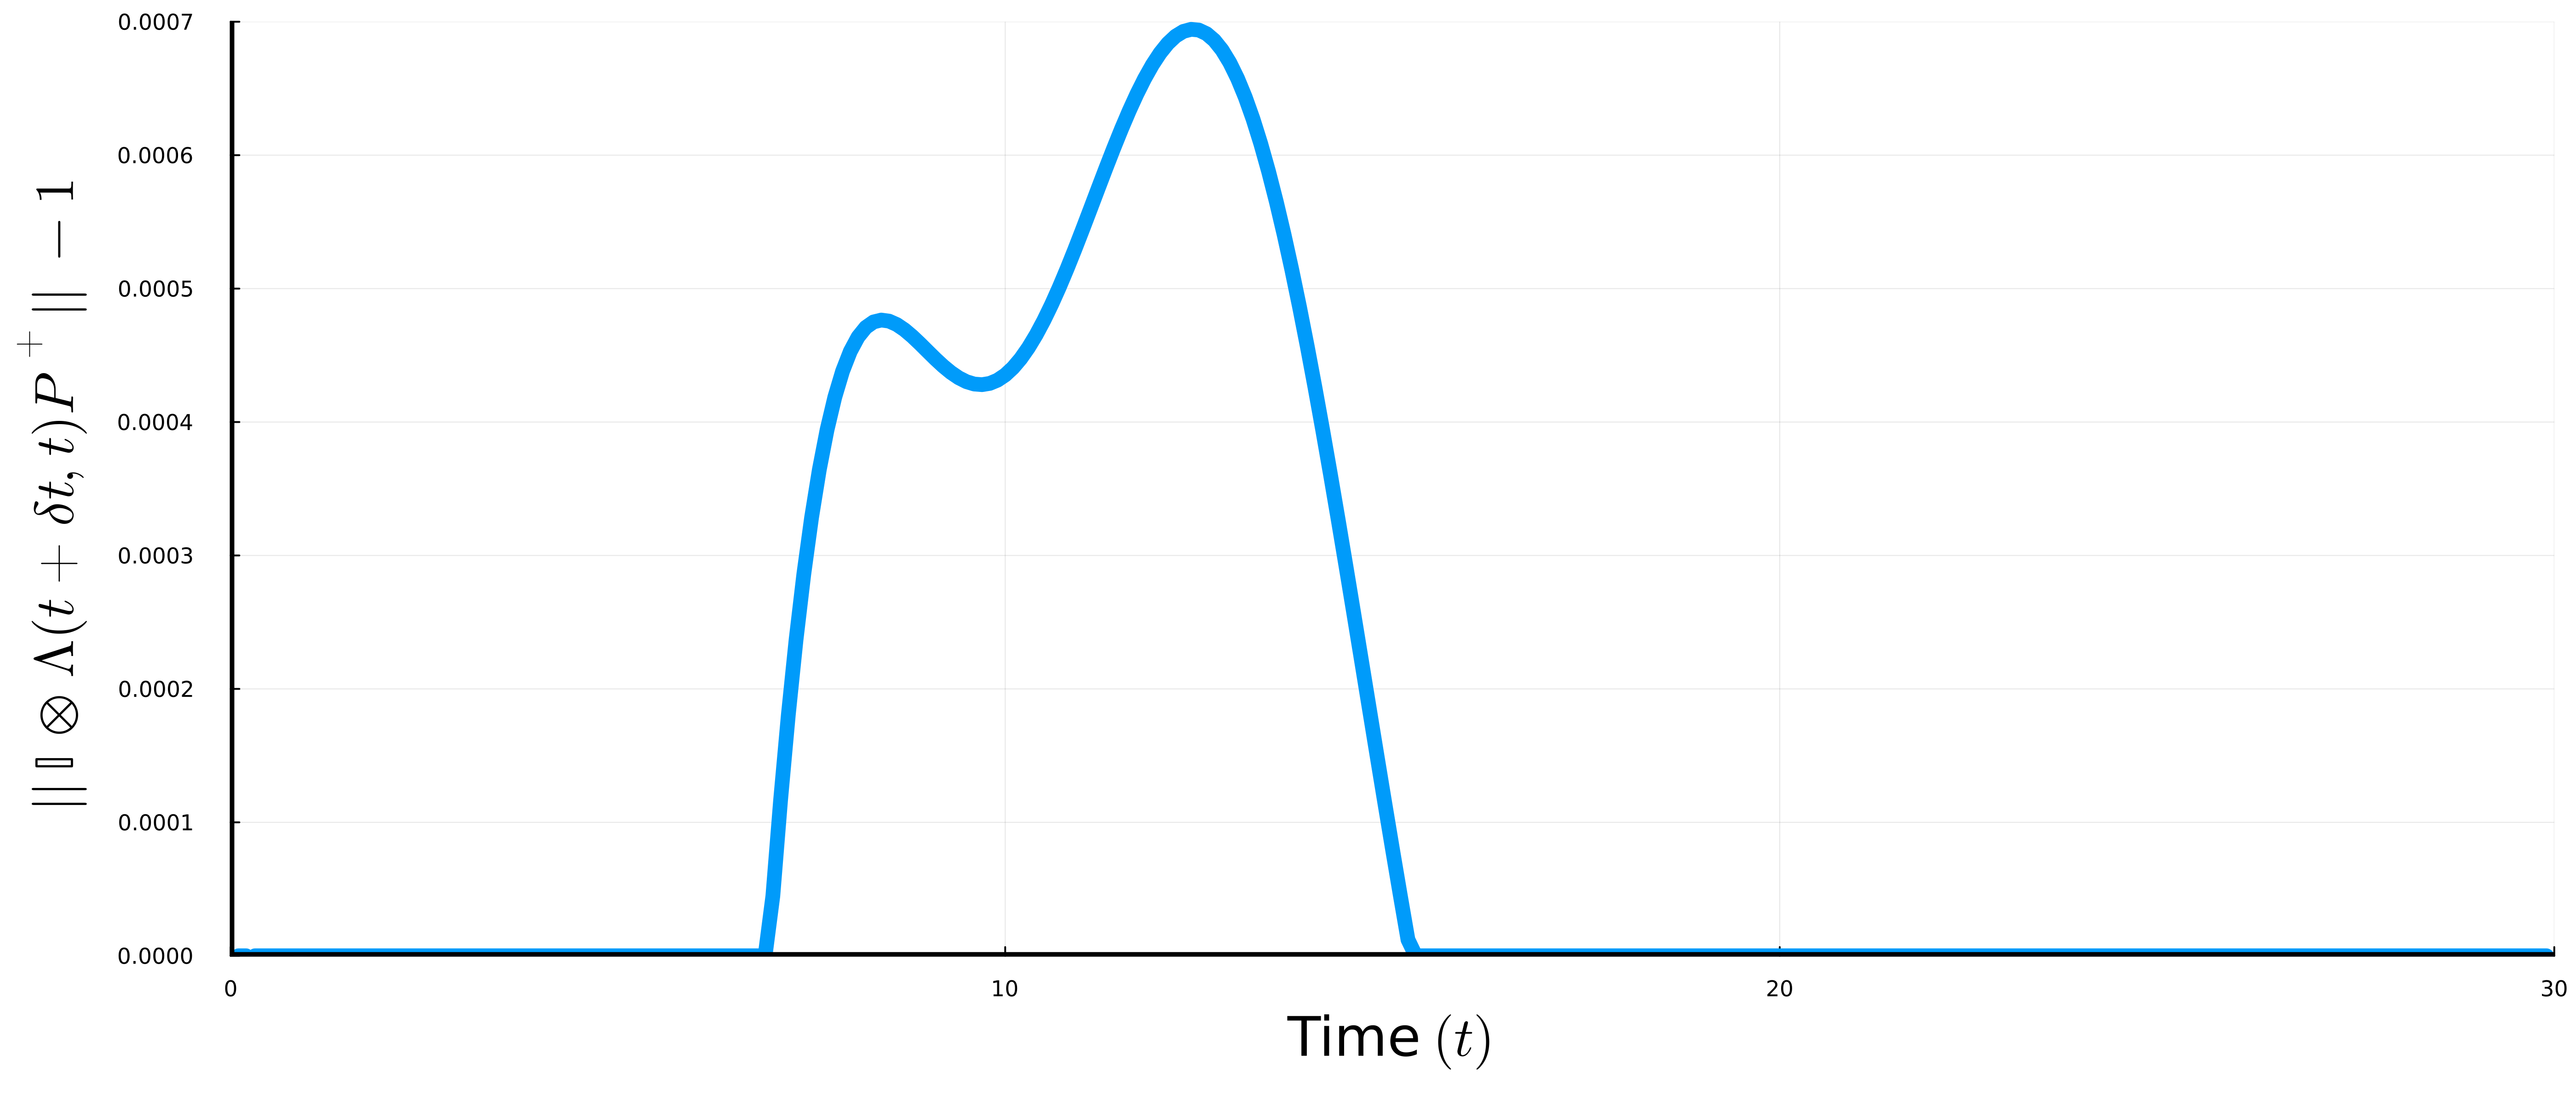

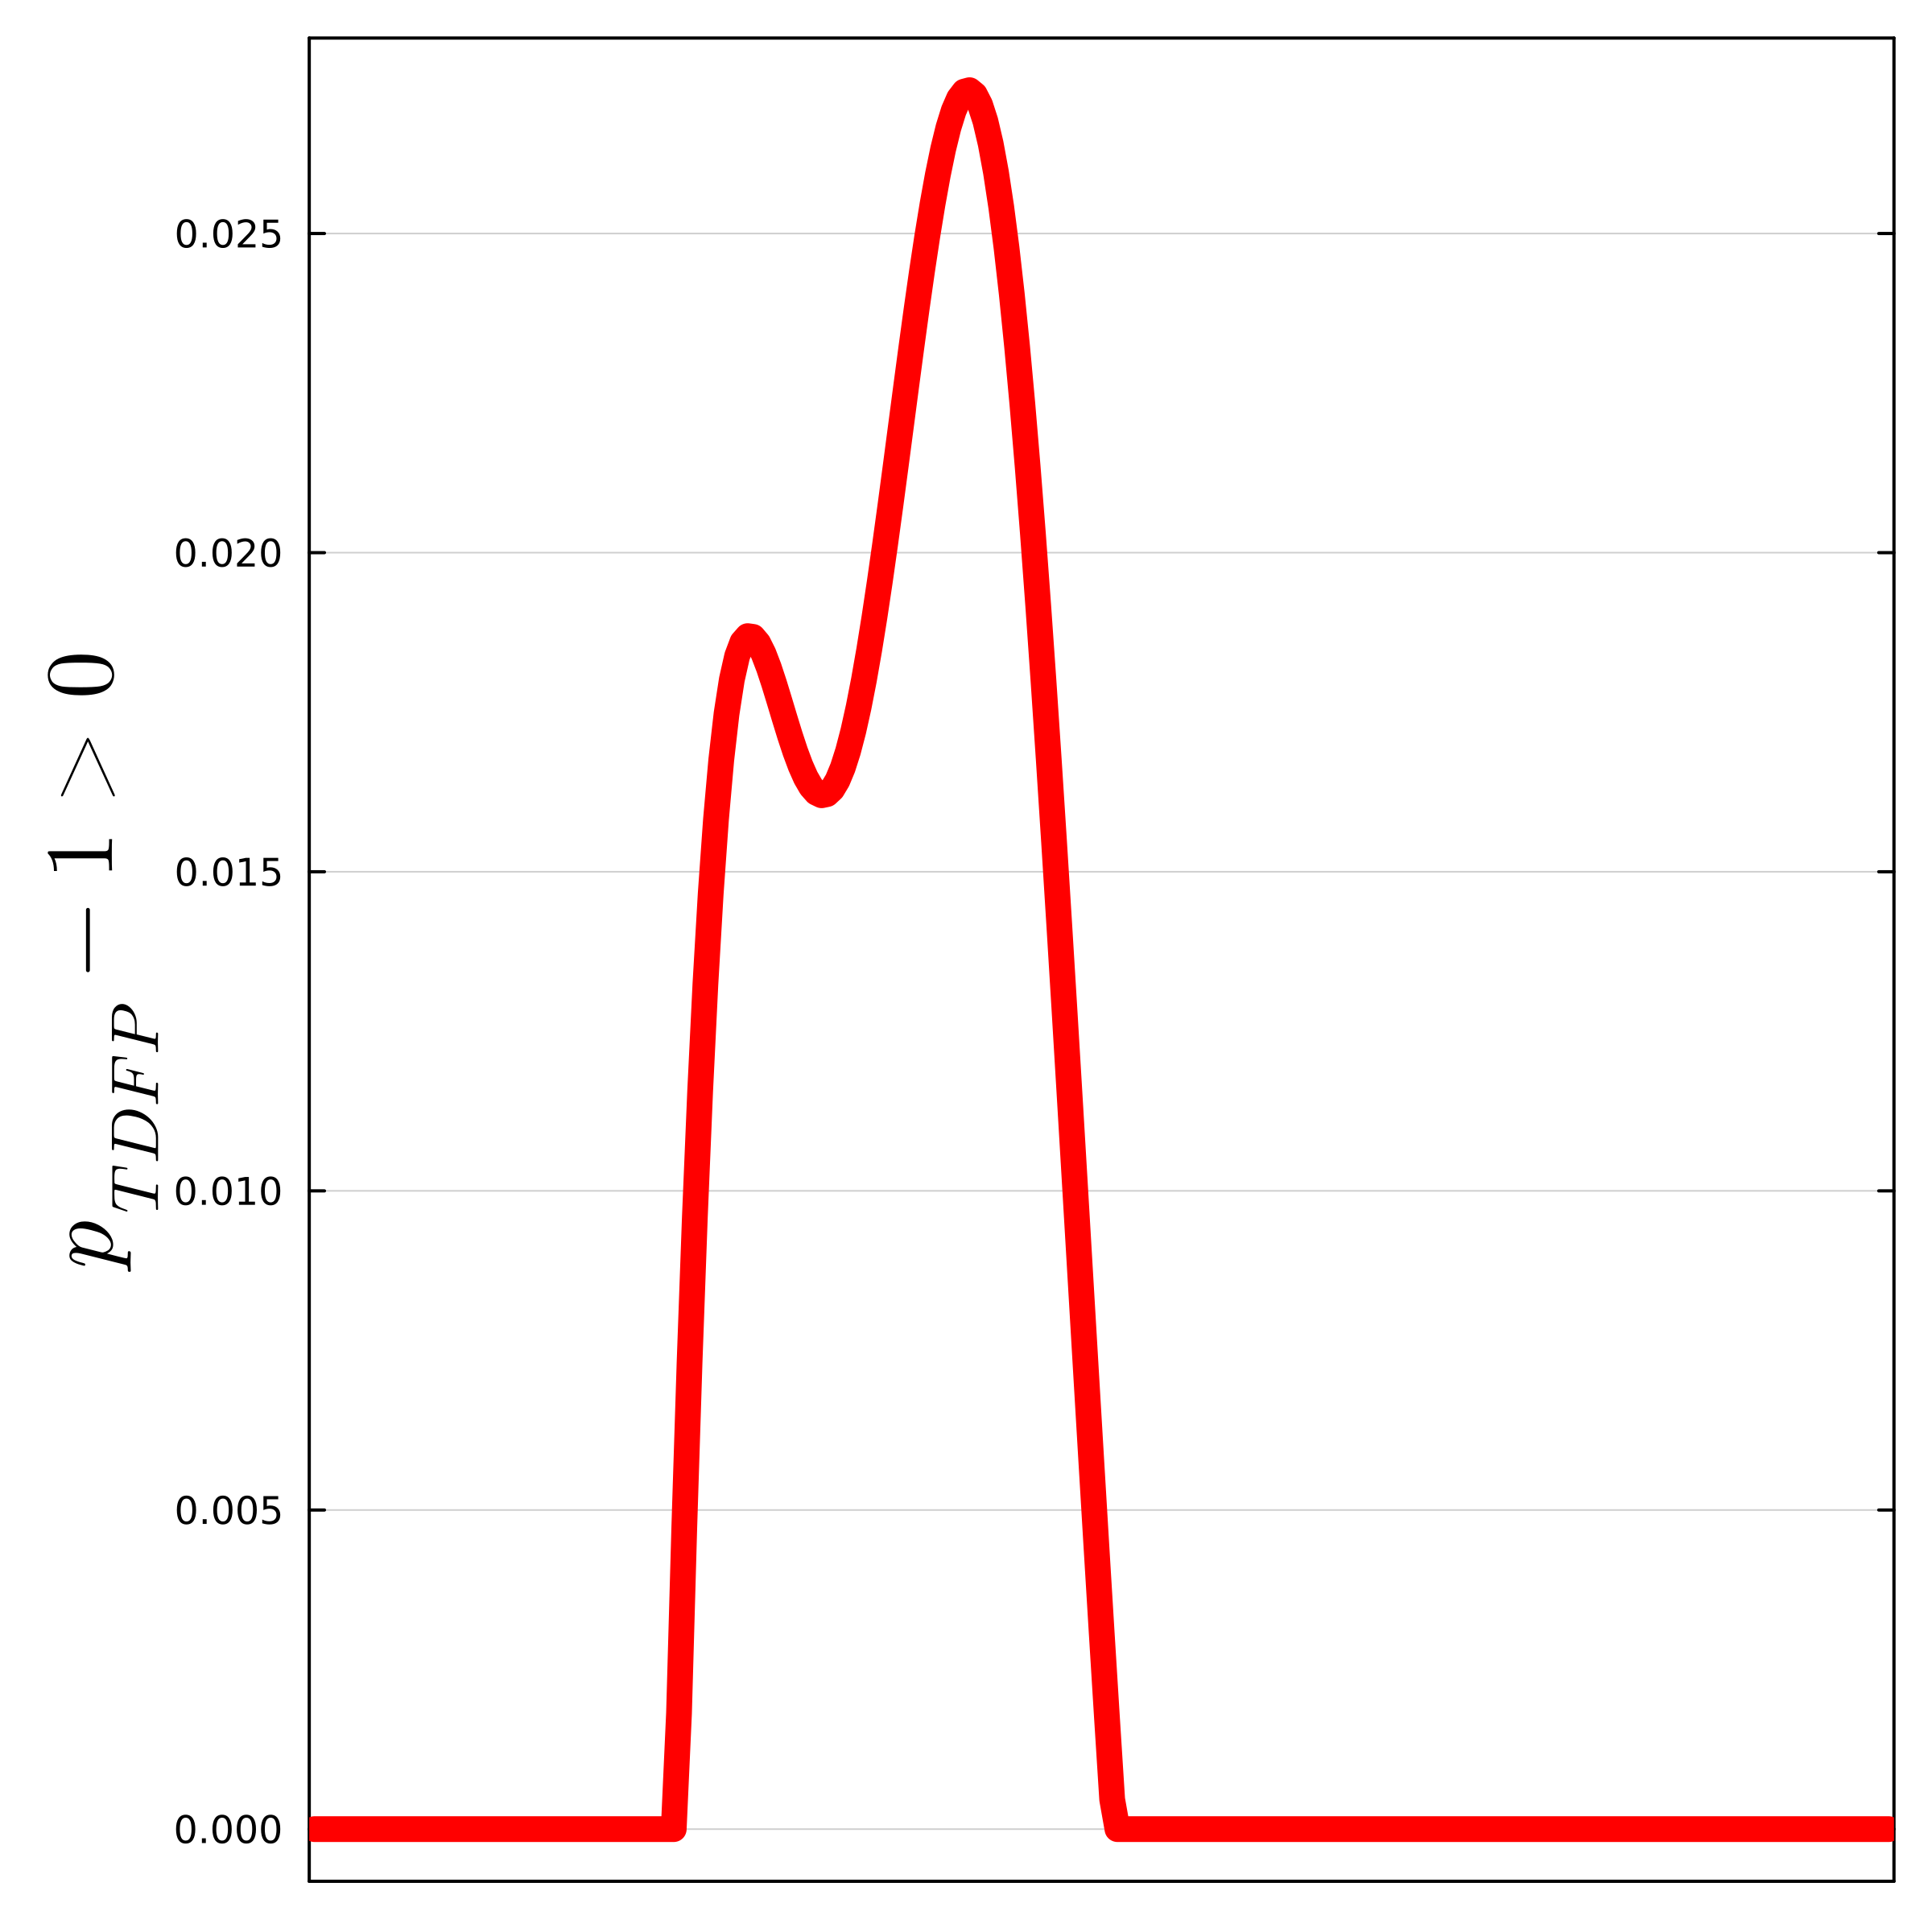

"C:\\Users\\ben_b\\Documents\\Git Repos\\AgeingManyBodyQuantumSys\\2ndTerm\\PosterPlots\\TDFPbox.svg"

In [38]:
"""
for i in 1:length(TDFP)
        TDFP[i] = (TDFP[i] > 1.0) ? TDFP[i] -1.0 : 0.0
end
"""
p1 = plot(times, diff, xlabel="Time \$(t)\$", ylabel="\$||\\mathbb{I} \\otimes \\Lambda(t+\\delta t, t) P^+ || - 1\$",
        legend=false, lw=8, dpi=400, size=(1400,600), xlims = (0.0,T), ylims=(0.0, 0.0007),
         guidefontsize=20, left_margin=10mm, bottom_margin=10mm)
vline!(p1, [0.0], lw=4, c=:black, label="")
hline!(p1, [0.0], lw=4, c=:black, label="")
display(p1)
savefig(p1, "C:\\Users\\ben_b\\Documents\\Git Repos\\AgeingManyBodyQuantumSys\\2ndTerm\\PosterPlots\\RHP.svg")
p2 = plot(times, TDFP, xticks=false, ylabel="\$p_{TDFP} - 1 > 0\$", c=:red,
        legend=false, lw=8, dpi=400, size=(600,600), xlims = (0.0,T), framestyle=:box,
         guidefontsize=20, left_margin=2mm, bottom_margin=2mm)
display(p2)
savefig(p2, "C:\\Users\\ben_b\\Documents\\Git Repos\\AgeingManyBodyQuantumSys\\2ndTerm\\PosterPlots\\TDFPbox.svg")
